In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
prev_years_df = pd.read_csv("ice_removals_fy12-23ytd2.csv", sep="|")

/var/folders/lx/9nt__35s79d_0j0wcwz1yrx80000gn/T/ipykernel_84879/1949459585.py:1: DtypeWarning: Columns (0: case_close_date, 1: apprehension_method_code, 2: processing_disposition_code, 3: arrest_date, 4: processing_disposition, 5: removal_date, 6: case_closed_date) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_years_df = pd.read_csv("ice_removals_fy12-23ytd2.csv", sep="|")


In [3]:
prev_years_df["departed_date"] = pd.to_datetime(
    prev_years_df["departed_date"],
    format="%m/%d/%Y",   # optional but faster if consistent
    errors="coerce"
)

# Create a NEW column with just the year
prev_years_df["departed_year"] = (
    prev_years_df["departed_date"]
    .dt.year
    .astype("Int64")
)

prev_years_df_modif = prev_years_df[["departed_year", "citizenship_country"]]
print(prev_years_df_modif.head())


   departed_year citizenship_country
0           2012              MEXICO
1           2011              MEXICO
2           2012              MEXICO
3           2012           GUATEMALA
4           2012              MEXICO


In [4]:
df = IR_df = pd.read_csv("ICERemovalData_RecentYears.csv",
                        encoding='latin-1')

In [5]:
ctdc = pd.read_csv("CTDC_global_synthetic_data_v2025.csv")

In [6]:
print(df.head())
#print(ctdc.head())

  Arresting Agency          Criminality Area of Responsibility (AOR)  \
0              CBP  Criminal Conviction                      Atlanta   
1              CBP  Criminal Conviction                      Atlanta   
2              CBP  Criminal Conviction                      Atlanta   
3              CBP  Criminal Conviction                      Atlanta   
4              CBP  Criminal Conviction                      Atlanta   

  Country of Citizenship  Fiscal Year  Fiscal Quarter  Fiscal Month  \
0            EL SALVADOR         2024               2             4   
1              GUATEMALA         2021               1             1   
2              GUATEMALA         2021               1             2   
3              GUATEMALA         2023               1             2   
4              GUATEMALA         2023               2             4   

  Month-Year  Removals  
0   Jan 2024        10  
1   Oct 2020        25  
2   Nov 2020        18  
3   Nov 2022        13  
4   Jan 2023   

In [7]:
prev_country_year_counts = (
    prev_years_df_modif
        .groupby(["departed_year", "citizenship_country"])
        .size()
        .reset_index(name="frequency")
)

print(prev_country_year_counts.head())

   departed_year citizenship_country  frequency
0           2010             ALBANIA          1
1           2010           ARGENTINA          3
2           2010             ARMENIA          2
3           2010             BAHAMAS          1
4           2010          BANGLADESH          4


In [8]:
iso = pd.read_csv("ISO_codes.csv")
iso = iso[["name", "alpha-3"]]

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

iso_mapping = dict(zip(iso["name"].str.lower(), iso["name"]))

manual_mappings = {
'bolivia': 'Bolivia, Plurinational State of',
    'burma': 'Myanmar',
    'china, peoples republic of': 'China',
    'iran': 'Iran, Islamic Republic of',
    'korea': 'Korea, Republic of',
    'laos': 'Lao People\'s Democratic Republic',
    'netherlands': 'Netherlands, Kingdom of the',
    'russia': 'Russian Federation',
    'serbia and montenegro': 'Serbia',
    'south korea': 'Korea, Republic of',
    'syria': 'Syrian Arab Republic',
    'taiwan': 'Taiwan, Province of China',
    'turkey': 'Türkiye',
    'united kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'venezuela': 'Venezuela, Bolivarian Republic of',
    'vietnam': 'Viet Nam',
    'yugoslavia': 'Serbia',
    'antigua-barbuda': 'Antigua and Barbuda',
    'bosnia-herzegovina': 'Bosnia and Herzegovina',
    'british virgin islands': 'Virgin Islands (British)',
    'cape verde': 'Cabo Verde',
    'czech republic': 'Czechia',
    'czechoslovakia': 'Czechia',
    'dem rep of the congo': 'Congo, Democratic Republic of the',
    'ivory coast': 'Côte d\'Ivoire',
    'macedonia': 'North Macedonia',
    'moldova': 'Moldova, Republic of',
    'st. kitts-nevis': 'Saint Kitts and Nevis',
    'st. lucia': 'Saint Lucia',
    'st. vincent-grenadines': 'Saint Vincent and the Grenadines',
    'tanzania': 'Tanzania, United Republic of',
    'netherlands antilles': 'Curaçao',
    'ussr': 'Russian Federation',
    'swaziland': 'Eswatini',
    'macau': 'Macao',
    'north korea': 'Korea, Democratic People\'s Republic of'
}

def map_country(country):
    country_lower = country.lower()
    if country_lower in manual_mappings:
        return manual_mappings[country_lower]
    return iso_mapping.get(country_lower, country)

prev_country_year_counts["citizenship_country"] = prev_country_year_counts["citizenship_country"].apply(map_country)

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

print(prev_country_year_counts.head())

prev_country_year_counts = prev_country_year_counts.merge(
    iso[["name", "alpha-3"]],
    left_on="citizenship_country",
    right_on="name",
    how="left"
)
prev_country_year_counts = prev_country_year_counts.drop(columns=["name"])
print(prev_country_year_counts.head())


<StringArray>
[                   'BOLIVIA',                      'BURMA',
 'CHINA, PEOPLES REPUBLIC OF',                       'IRAN',
                      'KOREA',                       'LAOS',
                'NETHERLANDS',                     'RUSSIA',
      'SERBIA AND MONTENEGRO',                'SOUTH KOREA',
                      'SYRIA',                     'TAIWAN',
                     'TURKEY',             'UNITED KINGDOM',
                  'VENEZUELA',                    'VIETNAM',
                 'YUGOSLAVIA',            'ANTIGUA-BARBUDA',
         'BOSNIA-HERZEGOVINA',     'BRITISH VIRGIN ISLANDS',
                 'CAPE VERDE',             'CZECH REPUBLIC',
             'CZECHOSLOVAKIA',       'DEM REP OF THE CONGO',
                'IVORY COAST',                     'KOSOVO',
                  'MACEDONIA',                    'MOLDOVA',
            'ST. KITTS-NEVIS',                  'ST. LUCIA',
     'ST. VINCENT-GRENADINES',                   'TANZANIA',
          

In [9]:
prev_country_year_counts

,departed_year,citizenship_country,frequency,alpha-3
0,2010,Albania,1,ALB
1,2010,Argentina,3,ARG
2,2010,Armenia,2,ARM
3,2010,Bahamas,1,BHS
4,2010,Bangladesh,4,BGD
...,...,...,...,...
2330,2023,United Kingdom of Great Britain and Northern I...,5,GBR
2331,2023,Uruguay,1,URY
2332,2023,Uzbekistan,4,UZB
2333,2023,"Venezuela, Bolivarian Republic of",34,VEN


In [10]:
removals_df = (
    df
    .groupby(
        ["Country of Citizenship", "Fiscal Year"]
    )
    .size()
    .reset_index(name="Number of Records")
)

print(removals_df.head())

print(ctdc.head())

  Country of Citizenship  Fiscal Year  Number of Records
0            AFGHANISTAN         2024                  3
1            AFGHANISTAN         2025                  1
2                 ANGOLA         2023                  1
3                 ANGOLA         2024                  1
4             BANGLADESH         2024                  6
   yearOfRegistration gender ageBroad citizenship CountryOfExploitation  \
0              2015.0    Man   30--38         UKR                   RUS   
1              2015.0    Man   30--38         UKR                   RUS   
2              2015.0    Man   30--38         UKR                   RUS   
3              2015.0    Man   30--38         UKR                   RUS   
4              2015.0    Man   30--38         UKR                   RUS   

     traffickMonths  meansDebtBondageEarnings  meansThreats  \
0  13--24 (1-2 yrs)                       1.0           1.0   
1  13--24 (1-2 yrs)                       1.0           1.0   
2  13--24 (1-2 yrs

In [11]:
ctdc["start_year"] = ctdc["traffickMonths"].str.extract(r'\((.*?)\)', expand=False)
ctdc["start_year"] = ctdc["start_year"].str.replace(r'\s*yrs?', '', regex=True)
#ctdc = ctdc[ctdc["start_year"] == "0-1"]

In [12]:
ctdc_clean = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
print(ctdc_clean['yearOfRegistration'].unique())


[2003. 2006. 2010. 2013. 2014. 2015. 2017. 2018. 2020. 2023. 2004. 2005.
 2007. 2009. 2011. 2012. 2016. 2019. 2021. 2022. 2008. 2002.]


In [13]:
ctdc = ctdc.dropna(subset=["yearOfRegistration"])
ctdc["yearOfRegistration"] = ctdc["yearOfRegistration"].astype(int)
ctdc["yearOfRegistration"].dtype

ctdc.head()

ctdc_grouped = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
ctdc_grouped.head()


,citizenship,yearOfRegistration,count
0,AFG,2003,12
1,AFG,2006,10
2,AFG,2010,9
3,AFG,2013,86
4,AFG,2014,166


In [14]:
removals_df = removals_df.rename(columns={
    "Country of Citizenship": "CountryOfCitizenship",
    "Fiscal Year": "FiscalYear",
    "Number of Records": "Frequency"
})

iso = iso[["name", "alpha-3"]]

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

country_mapping = {
    "CHINA, PEOPLES REPUBLIC OF": "China",
    "BOLIVIA": "Bolivia, Plurinational State of",
    "DEM REP OF THE CONGO": "Congo, Democratic Republic of the",
    "REPUBLIC OF TÜRKIYE": "Türkiye",
    "RUSSIA": "Russian Federation",
    "TURKIYE": "Türkiye",
    "UNITED KINGDOM": "United Kingdom of Great Britain and Northern Ireland",
    "VENEZUELA": "Venezuela, Bolivarian Republic of"
}

removals_df["CountryOfCitizenship"] = (
    removals_df["CountryOfCitizenship"]
    .replace(country_mapping)
)

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

removals_df["_country_key"] = removals_df["CountryOfCitizenship"].str.strip().str.lower()
iso["_country_key"] = iso["name"].str.strip().str.lower()

removals_df = removals_df.merge(
    iso[["_country_key", "alpha-3"]],
    on="_country_key",
    how="left"
)

print(removals_df.head())

removals_df.to_csv("merged_df.csv", index=False)

<StringArray>
[                   'BOLIVIA', 'CHINA, PEOPLES REPUBLIC OF',
       'DEM REP OF THE CONGO',       'REPUBLIC OF TÃRKIYE',
                     'RUSSIA',                    'TURKIYE',
             'UNITED KINGDOM',                  'VENEZUELA']
Length: 8, dtype: str
<StringArray>
['REPUBLIC OF TÃRKIYE']
Length: 1, dtype: str
  CountryOfCitizenship  FiscalYear  Frequency _country_key alpha-3
0          AFGHANISTAN        2024          3  afghanistan     AFG
1          AFGHANISTAN        2025          1  afghanistan     AFG
2               ANGOLA        2023          1       angola     AGO
3               ANGOLA        2024          1       angola     AGO
4           BANGLADESH        2024          6   bangladesh     BGD


In [15]:
print(ctdc_grouped.head())
print(prev_country_year_counts.head())


  citizenship  yearOfRegistration  count
0         AFG                2003     12
1         AFG                2006     10
2         AFG                2010      9
3         AFG                2013     86
4         AFG                2014    166
   departed_year citizenship_country  frequency alpha-3
0           2010             Albania          1     ALB
1           2010           Argentina          3     ARG
2           2010             Armenia          2     ARM
3           2010             Bahamas          1     BHS
4           2010          Bangladesh          4     BGD


In [16]:
print(ctdc_grouped.head())

ctdc_grouped.to_csv("ctdc_grouped.csv", index=False)

recent_year_mergrged = removals_df.merge(
    ctdc_grouped,
    left_on=["alpha-3", "FiscalYear"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

recent_year_mergrged["_merge"].value_counts()

print(recent_year_mergrged.head())

recent_year_mergrged = recent_year_mergrged.rename(columns={
    "Frequency": "deportee_freq",
    "count": "traffick_freq"
})

recent_year_mergrged = recent_year_mergrged.dropna(
    subset=["deportee_freq", "traffick_freq"]
)

  citizenship  yearOfRegistration  count
0         AFG                2003     12
1         AFG                2006     10
2         AFG                2010      9
3         AFG                2013     86
4         AFG                2014    166
  CountryOfCitizenship  FiscalYear  Frequency _country_key alpha-3  \
0          AFGHANISTAN        2024          3  afghanistan     AFG   
1          AFGHANISTAN        2025          1  afghanistan     AFG   
2               ANGOLA        2023          1       angola     AGO   
3               ANGOLA        2024          1       angola     AGO   
4           BANGLADESH        2024          6   bangladesh     BGD   

  citizenship  yearOfRegistration  count     _merge  
0         NaN                 NaN    NaN  left_only  
1         NaN                 NaN    NaN  left_only  
2         NaN                 NaN    NaN  left_only  
3         NaN                 NaN    NaN  left_only  
4         NaN                 NaN    NaN  left_only  


In [17]:
recent_year_mergrged

,CountryOfCitizenship,FiscalYear,deportee_freq,_country_key,alpha-3,citizenship,yearOfRegistration,traffick_freq,_merge
9,BRAZIL,2021,33,brazil,BRA,BRA,2021.0,9.0,both
10,BRAZIL,2022,40,brazil,BRA,BRA,2022.0,11.0,both
11,BRAZIL,2023,33,brazil,BRA,BRA,2023.0,19.0,both
14,CAMEROON,2021,3,cameroon,CMR,CMR,2021.0,8.0,both
19,China,2023,1,china,CHN,CHN,2023.0,22.0,both
22,COLOMBIA,2021,8,colombia,COL,COL,2021.0,30.0,both
23,COLOMBIA,2022,75,colombia,COL,COL,2022.0,46.0,both
24,COLOMBIA,2023,129,colombia,COL,COL,2023.0,113.0,both
29,CUBA,2021,2,cuba,CUB,CUB,2021.0,7.0,both
30,CUBA,2023,5,cuba,CUB,CUB,2023.0,6.0,both


In [18]:
recent_year_mergrged

,CountryOfCitizenship,FiscalYear,deportee_freq,_country_key,alpha-3,citizenship,yearOfRegistration,traffick_freq,_merge
9,BRAZIL,2021,33,brazil,BRA,BRA,2021.0,9.0,both
10,BRAZIL,2022,40,brazil,BRA,BRA,2022.0,11.0,both
11,BRAZIL,2023,33,brazil,BRA,BRA,2023.0,19.0,both
14,CAMEROON,2021,3,cameroon,CMR,CMR,2021.0,8.0,both
19,China,2023,1,china,CHN,CHN,2023.0,22.0,both
22,COLOMBIA,2021,8,colombia,COL,COL,2021.0,30.0,both
23,COLOMBIA,2022,75,colombia,COL,COL,2022.0,46.0,both
24,COLOMBIA,2023,129,colombia,COL,COL,2023.0,113.0,both
29,CUBA,2021,2,cuba,CUB,CUB,2021.0,7.0,both
30,CUBA,2023,5,cuba,CUB,CUB,2023.0,6.0,both


In [19]:
prev_year_merged = prev_country_year_counts.merge(
    ctdc_grouped,
    left_on=["alpha-3", "departed_year"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

prev_year_merged = prev_year_merged.rename(columns={
    "frequency": "deportee_freq",
    "count": "traffick_freq"
})

prev_year_merged = prev_year_merged.dropna(
    subset=["deportee_freq", "traffick_freq"]
)

In [20]:
prev_year_merged

,departed_year,citizenship_country,deportee_freq,alpha-3,citizenship,yearOfRegistration,traffick_freq,_merge
0,2010,Albania,1,ALB,ALB,2010.0,2.0,both
4,2010,Bangladesh,4,BGD,BGD,2010.0,7.0,both
5,2010,"Bolivia, Plurinational State of",3,BOL,BOL,2010.0,23.0,both
6,2010,Brazil,207,BRA,BRA,2010.0,6.0,both
7,2010,Myanmar,1,MMR,MMR,2010.0,28.0,both
...,...,...,...,...,...,...,...,...
2325,2023,Thailand,3,THA,THA,2023.0,33.0,both
2329,2023,Ukraine,1,UKR,UKR,2023.0,117.0,both
2332,2023,Uzbekistan,4,UZB,UZB,2023.0,35.0,both
2333,2023,"Venezuela, Bolivarian Republic of",34,VEN,VEN,2023.0,41.0,both


In [21]:
recent_year_merged_clean = recent_year_mergrged[
    ["FiscalYear", "alpha-3", "deportee_freq", "traffick_freq"]
]

recent_year_merged_clean = recent_year_merged_clean.rename(columns={
    "FiscalYear": "year",
    "citizenship": "country",
    "alpha-3_x": "alpha-3"
})

In [22]:
prev_year_merged
prev_year_merged_clean = prev_year_merged[
    ["departed_year", "alpha-3", "deportee_freq", "traffick_freq"]
]

prev_year_merged_clean = prev_year_merged_clean.rename(columns={
    "departed_year": "year",
    "citizenship_country": "country"
})

In [23]:
print(recent_year_merged_clean.head())

    year alpha-3  deportee_freq  traffick_freq
9   2021     BRA             33            9.0
10  2022     BRA             40           11.0
11  2023     BRA             33           19.0
14  2021     CMR              3            8.0
19  2023     CHN              1           22.0


In [24]:
print(prev_year_merged_clean.head())

   year alpha-3  deportee_freq  traffick_freq
0  2010     ALB              1            2.0
4  2010     BGD              4            7.0
5  2010     BOL              3           23.0
6  2010     BRA            207            6.0
7  2010     MMR              1           28.0


In [25]:
counts1 = recent_year_merged_clean.groupby("year").size()
counts2 = prev_year_merged_clean.groupby("year").size()
year_counts = pd.concat([counts1, counts2], axis=1, keys=["File 1", "File 2"])
year_counts = year_counts.fillna(0).astype(int)
print(year_counts)

prev_year_merged_clean.to_csv('regression_data_output.csv', index=None)


      File 1  File 2
year                
2021      14      50
2022       9      44
2023      15      33
2010       0      25
2011       0      43
2012       0      39
2013       0      47
2014       0      46
2015       0      55
2016       0      56
2017       0      56
2018       0      57
2019       0      52
2020       0      50


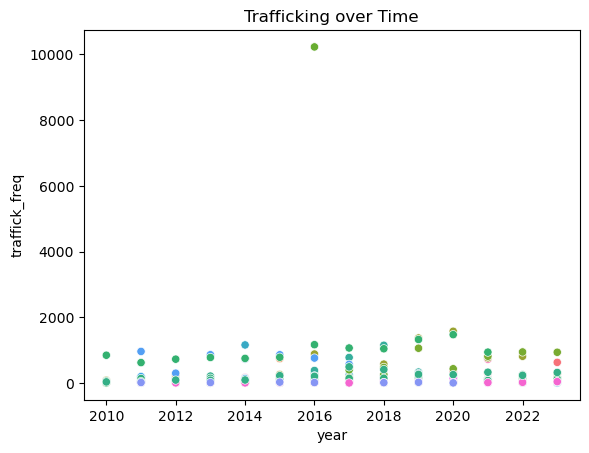

In [26]:
sns.scatterplot(data=prev_year_merged_clean, x="year", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking over Time")
plt.show()

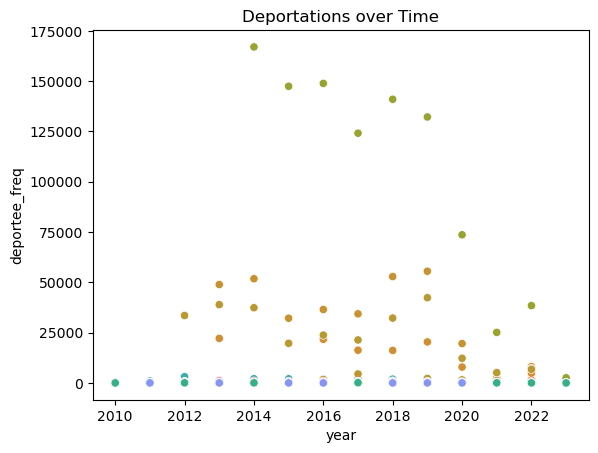

In [27]:
sns.scatterplot(data=prev_year_merged_clean, x="year", y="deportee_freq", hue="alpha-3", legend=False)
plt.title("Deportations over Time")
plt.show()

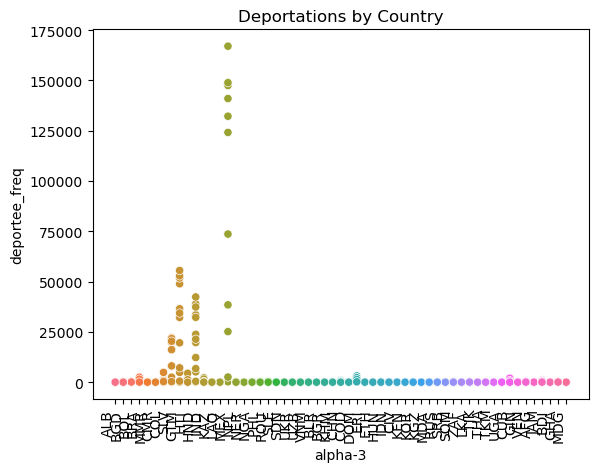

In [28]:
sns.scatterplot(data=prev_year_merged_clean, x="alpha-3", y="deportee_freq", hue="alpha-3", legend=False)
plt.title("Deportations by Country")
plt.xticks(rotation=90, ha='right')
plt.show()

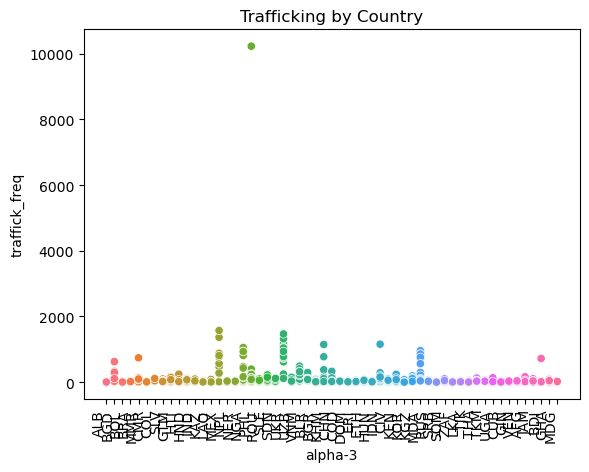

In [29]:
sns.scatterplot(data=prev_year_merged_clean, x="alpha-3", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking by Country")
plt.xticks(rotation=90, ha='right')
plt.show()

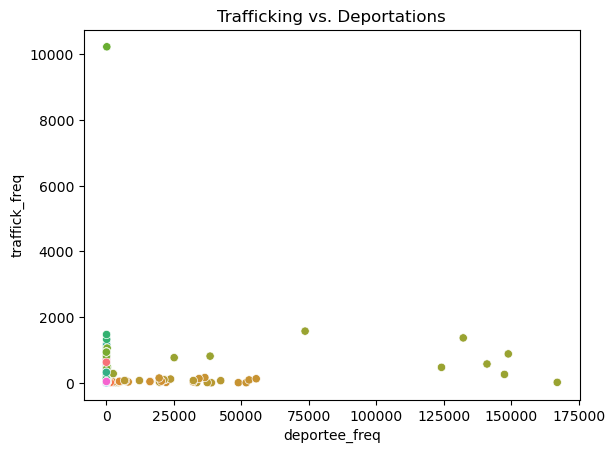

In [30]:
sns.scatterplot(data=prev_year_merged_clean, x="deportee_freq", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking vs. Deportations")
plt.show()

In [31]:
model_simple = smf.ols('traffick_freq ~ deportee_freq', data=prev_year_merged_clean).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          traffick_freq   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     8.195
Date:                Tue, 10 Mar 2026   Prob (F-statistic):            0.00433
Time:                        14:39:25   Log-Likelihood:                -4910.6
No. Observations:                 653   AIC:                             9825.
Df Residuals:                     651   BIC:                             9834.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       103.5059     17.796      5.816

In [32]:
iso_full = pd.read_csv("ISO_codes.csv")

iso_full = iso_full[["alpha-3", "region", "sub-region","name"]]

iso_full["alpha-3"] = iso_full["alpha-3"].astype(str)

prev_year_merged_clean["alpha-3"] = prev_year_merged_clean["alpha-3"].astype(str)

regression_with_region = prev_year_merged_clean.merge(
    iso_full,
    on="alpha-3",
    how="left"
)

print(regression_with_region.head())

   year alpha-3  deportee_freq  traffick_freq    region  \
0  2010     ALB              1            2.0    Europe   
1  2010     BGD              4            7.0      Asia   
2  2010     BOL              3           23.0  Americas   
3  2010     BRA            207            6.0  Americas   
4  2010     MMR              1           28.0      Asia   

                        sub-region                             name  
0                  Southern Europe                          Albania  
1                    Southern Asia                       Bangladesh  
2  Latin America and the Caribbean  Bolivia, Plurinational State of  
3  Latin America and the Caribbean                           Brazil  
4               South-eastern Asia                          Myanmar  


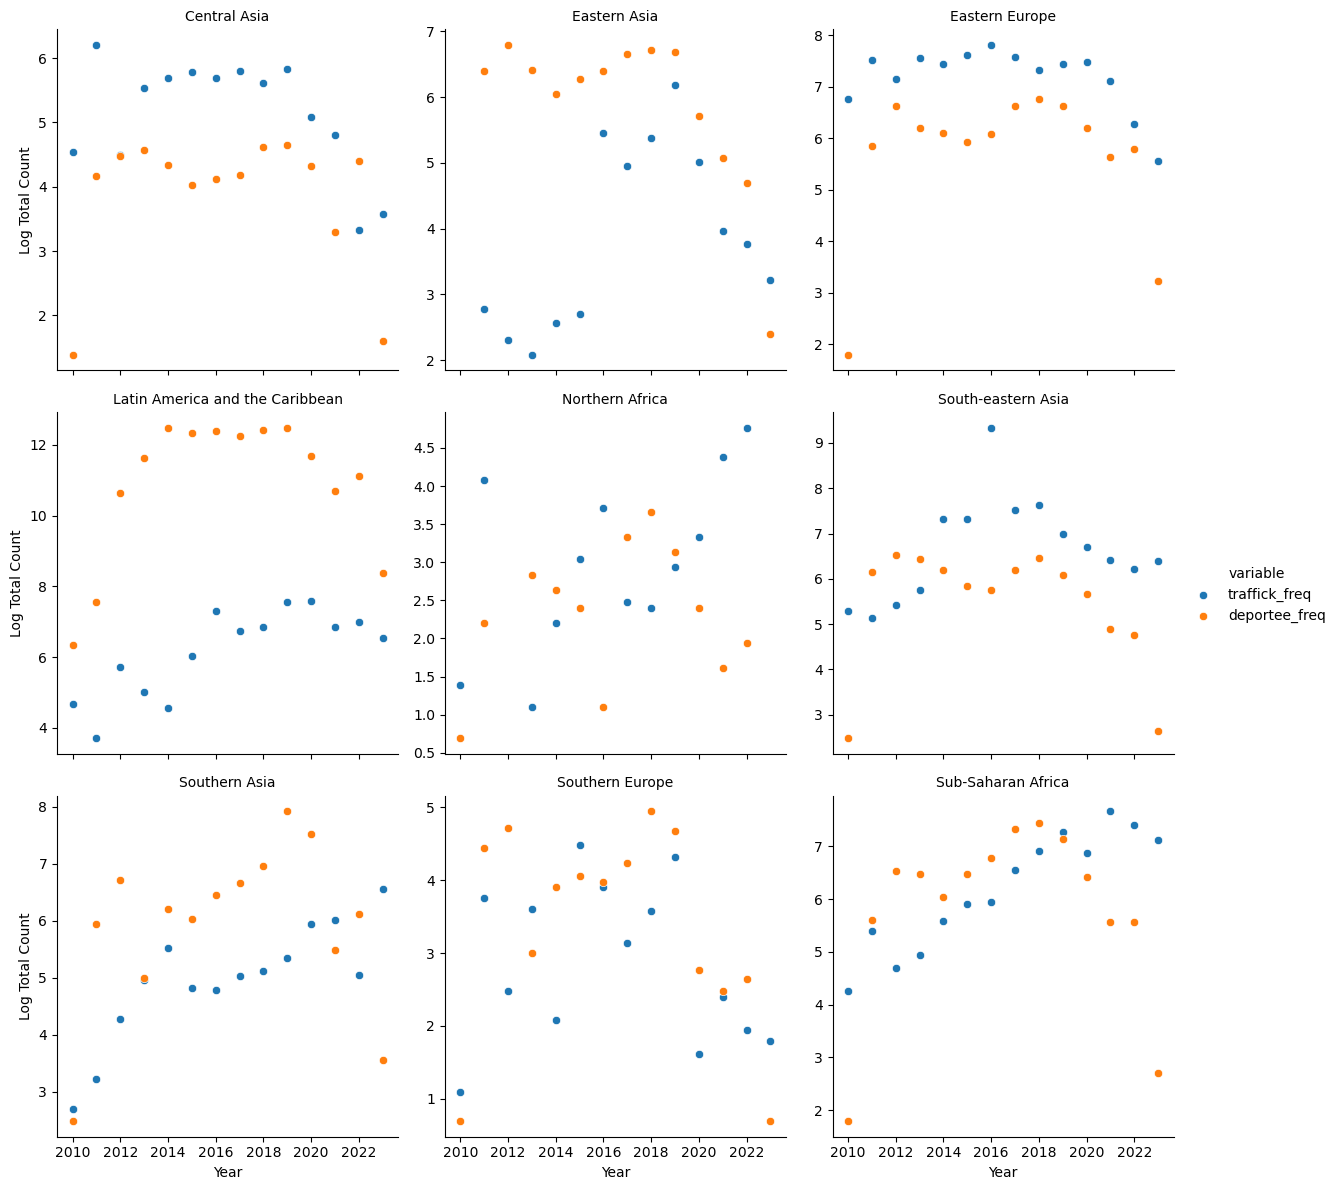

In [34]:
subregion_long = subregion_year.melt(
    id_vars=["sub-region", "year"],
    value_vars=["traffick_freq", "deportee_freq"],
    var_name="variable",
    value_name="total"
)

# Log transform
subregion_long["log_total"] = np.log1p(subregion_long["total"])

g = sns.FacetGrid(
    subregion_long,
    col="sub-region",
    col_wrap=3,
    hue="variable",
    sharey=False,
    height=4
)

g.map(sns.scatterplot, "year", "log_total")

g.add_legend()
g.set_axis_labels("Year", "Log Total Count")
g.set_titles("{col_name}")

plt.show()

In [35]:
output = []

for region in regression_with_region["sub-region"].dropna().unique():
    
    subset = regression_with_region[
        regression_with_region["sub-region"] == region
    ]
    
    if len(subset) > 5:
        model = smf.ols(
            "traffick_freq ~ deportee_freq",
            data=subset
        ).fit()
        
        output.append({
            "sub-region": region,
            "n_obs": len(subset),
            "coef": model.params["deportee_freq"],
            "p_value": model.pvalues["deportee_freq"],
            "r_squared": model.rsquared
        })

subregion_results = pd.DataFrame(output)

print(subregion_results.sort_values("p_value"))

                        sub-region  n_obs      coef       p_value  r_squared
2  Latin America and the Caribbean    134  0.004162  2.485943e-14   0.357117
4               Sub-Saharan Africa    164  0.392554  1.103811e-02   0.039205
8                     Eastern Asia     30  0.126143  1.407664e-02   0.196766
5                     Central Asia     55  0.739970  9.390804e-02   0.052041
3               South-eastern Asia     80  2.279104  1.443735e-01   0.027118
7                  Northern Africa     12 -1.401619  1.509542e-01   0.194757
1                    Southern Asia     56 -0.014903  6.847859e-01   0.003075
6                   Eastern Europe     90 -0.117220  7.988045e-01   0.000742
0                  Southern Europe     32 -0.006320  8.771028e-01   0.000810


In [45]:
country_totals = (
    regression_with_region
    .groupby(["alpha-3", "name"], as_index=False)
    .agg({
        "traffick_freq": "sum",
        "deportee_freq": "sum"
    })
)

# Step 2: Get top 15 by each metric
top_traffick = country_totals.nlargest(10, "traffick_freq")
top_deport = country_totals.nlargest(10, "deportee_freq")

# Step 3: Combine country lists
top_countries = (
    pd.concat([top_traffick[["alpha-3"]], top_deport[["alpha-3"]]])
    .drop_duplicates()
)

combined_top = country_totals[country_totals["alpha-3"].isin(top_countries["alpha-3"])] 

In [46]:
def get_individual_countries_regression(regression_with_region, combined_top):
    
    # List of countries to keep
    countries = combined_top["name"].unique()
    
    # Filter rows
    individual_countries_regression = regression_with_region[
        regression_with_region["name"].isin(countries)
    ].copy()
    
    return individual_countries_regression

In [47]:
individual_countries_regression = get_individual_countries_regression(
    regression_with_region, combined_top
)

print(individual_countries_regression.head())

print(individual_countries_regression.shape)
print(regression_with_region.shape)


   year alpha-3  deportee_freq  traffick_freq    region  \
1  2010     BGD              4            7.0      Asia   
3  2010     BRA            207            6.0  Americas   
6  2010     COL             18           17.0  Americas   
7  2010     SLV             55            6.0  Americas   
8  2010     GTM             34            7.0  Americas   

                        sub-region         name  
1                    Southern Asia   Bangladesh  
3  Latin America and the Caribbean       Brazil  
6  Latin America and the Caribbean     Colombia  
7  Latin America and the Caribbean  El Salvador  
8  Latin America and the Caribbean    Guatemala  
(233, 7)
(653, 7)


In [48]:
output = []

for country in individual_countries_regression["name"].dropna().unique():
    
    subset = individual_countries_regression[
        individual_countries_regression["name"] == country
    ]
    
    if len(subset) > 5:
        model = smf.ols(
            "traffick_freq ~ deportee_freq",
            data=subset
        ).fit()
        
        output.append({
            "name": country,
            "n_obs": len(subset),
            "coef": model.params["deportee_freq"],
            "p_value": model.pvalues["deportee_freq"],
            "r_squared": model.rsquared
        })

country_results = pd.DataFrame(output)

print(country_results.sort_values("p_value"))

                    name  n_obs      coef   p_value  r_squared
14              Cambodia     11  6.656659  0.028339   0.430539
12              Viet Nam     14  2.248046  0.050871   0.281663
3            El Salvador     11  0.001458  0.110570   0.258136
11               Ukraine     14  3.105152  0.117603   0.191512
17  Moldova, Republic of     13  6.522252  0.327626   0.087099
9                Nigeria     14 -0.841327  0.358056   0.070737
18               Jamaica     11 -0.022186  0.511617   0.049320
6               Honduras     13 -0.000450  0.546974   0.033917
5                  Haiti      9 -0.010272  0.634218   0.034124
1                 Brazil     12  0.002005  0.683396   0.017331
4              Guatemala     12  0.000350  0.684614   0.017191
0             Bangladesh     13 -0.275275  0.693915   0.014625
8                 Mexico     11  0.000512  0.850941   0.004139
13               Belarus     12 -0.382474  0.899945   0.001660
2               Colombia     14 -0.001008  0.899969   0

/Users/rishithhakker/miniforge3/envs/qss20/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning:

sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.

/Users/rishithhakker/miniforge3/envs/qss20/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning:

sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.



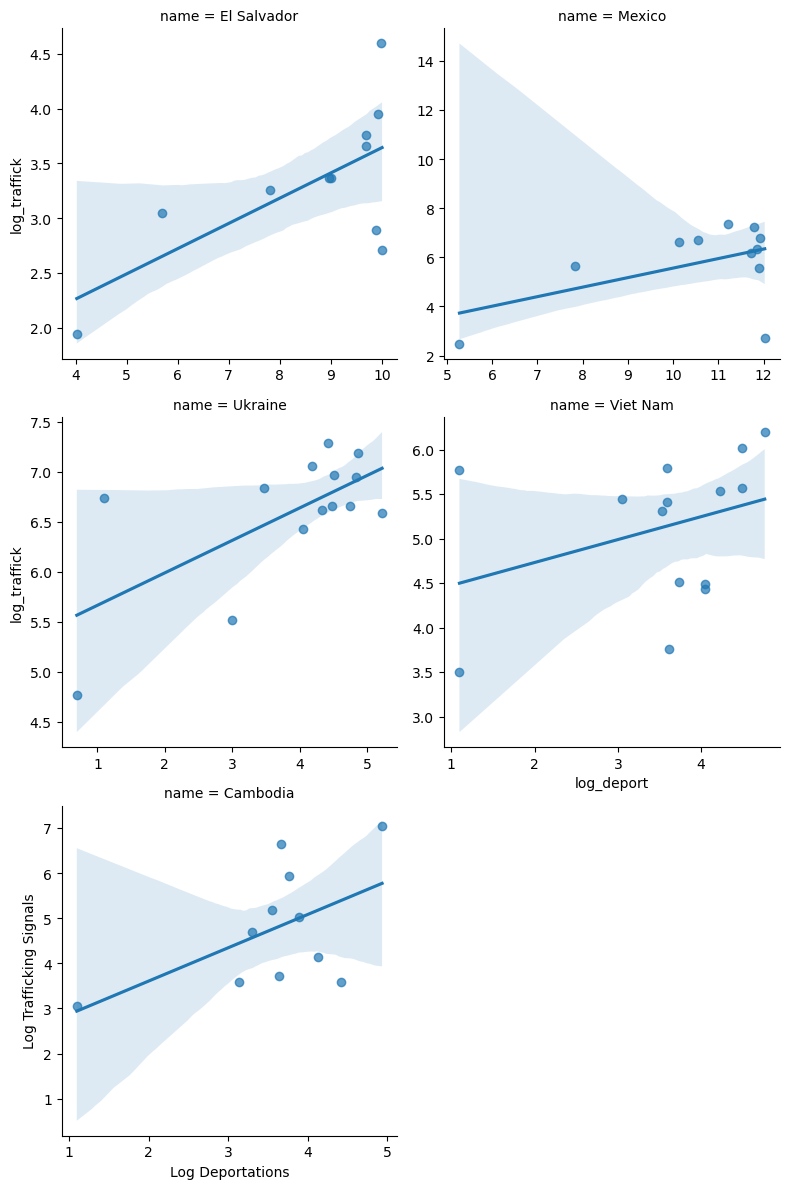

In [55]:
individual_countries_regression["log_traffick"] = np.log1p(
    individual_countries_regression["traffick_freq"]
)

individual_countries_regression["log_deport"] = np.log1p(
    individual_countries_regression["deportee_freq"]
)

countries = ["Cambodia", "Viet Nam", "El Salvador", "Ukraine", "Mexico"]

plot_data = individual_countries_regression[
    individual_countries_regression["name"].isin(countries)
]

sns.lmplot(
    data=plot_data,
    x="log_deport",
    y="log_traffick",
    col="name",
    col_wrap=2,
    height=4,
    scatter_kws={"alpha": 0.7},
    sharex=False,
    sharey=False
)

plt.xlabel("Log Deportations")
plt.ylabel("Log Trafficking Signals")

plt.show()

In [49]:
df = regression_with_region.copy()

df = (
    df.groupby(["name", "year"], as_index=False)
      .agg({
          "alpha-3": "first",
          "region": "first",
          "sub-region": "first",
          "traffick_freq": "sum",
          "deportee_freq": "sum"
      })
)

full_index = pd.MultiIndex.from_product(
    [df["name"].unique(),
     range(df["year"].min(), df["year"].max() + 1)],
    names=["name", "year"]
)

df = (
    df.set_index(["name", "year"])
      .reindex(full_index)
      .reset_index()
)

country_info = (
    regression_with_region[["name", "alpha-3", "region", "sub-region"]]
    .drop_duplicates()
)

df = df.merge(country_info, on="name", how="left")

df["traffick_freq"] = df["traffick_freq"].fillna(0)
df["deportee_freq"] = df["deportee_freq"].fillna(0)

df = df.sort_values(["name", "year"])

df["traffick_cum"] = df.groupby("name")["traffick_freq"].cumsum()
df["deportee_cum"] = df.groupby("name")["deportee_freq"].cumsum()

In [50]:
years = sorted(df["year"].unique())

df["log_deport_cum"] = np.log1p(df["deportee_cum"])
df["log_traffick_cum"] = np.log1p(df["traffick_cum"])

fig = go.Figure()

dff = df[df["year"] == years[0]]

fig.add_trace(
    go.Choropleth(
        locations=dff["alpha-3_y"],
        z=dff["log_deport_cum"],
        text=dff["name"],
        colorscale="Reds",
        colorbar_title="Log Cumulative Count",
        zmin=0,
        zmax=df["log_deport_cum"].max()
    )
)

frames = []
for year in years:
    
    dff = df[df["year"] == year]

    frames.append(
        go.Frame(
            data=[
                go.Choropleth(
                    locations=dff["alpha-3_y"],
                    z=dff["log_deport_cum"],
                    text=dff["name"],
                    colorscale="Reds",
                    zmin=0,
                    zmax=df["log_deport_cum"].max()
                )
            ],
            name=str(year)
        )
    )

fig.frames = frames

fig.update_layout(
    sliders=[{
        "steps": [
            {
                "method": "animate",
                "label": str(year),
                "args": [[str(year)], {"mode": "immediate"}],
            }
            for year in years
        ]
    }]
)

fig.update_layout(
    updatemenus=[{
        "buttons": [
            {
                "label": "Cumulative Deportations",
                "method": "restyle",
                "args": ["z", [df[df["year"] == years[0]]["log_deport_cum"]]],
            },
            {
                "label": "Cumulative Trafficking",
                "method": "restyle",
                "args": ["z", [df[df["year"] == years[0]]["log_traffick_cum"]]],
            },
        ],
        "direction": "down",
        "showactive": True,
        "x": 0.1,
        "y": 1.15,
    }]
)

fig.update_layout(
    title="Cumulative Global Deportations and Trafficking",
    geo=dict(projection_type="natural earth")
)

fig.show()